In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn import tree

: 

In [11]:
loan_data = pd.read_csv("/content/loan_approval_decision_tree_dataset.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [12]:
loan_data.head()

,Annual_Income,Credit_Score,Loan_Amount,Employment_Status,Education_Level,Existing_Debt,Loan_Status
0,141958,540,82097,Employed,Graduate,467010,Rejected
1,35795,863,716326,Unemployed,Postgraduate,82152,Rejected
2,20860,395,699150,Unemployed,Graduate,125036,Rejected
3,123694,784,280229,Self-Employed,High School,386193,Rejected
4,148106,706,168834,Employed,High School,26734,Approved


In [13]:
print("Rows and Columns :", loan_data.shape)

Rows and Columns : (200, 7)


In [14]:
print("Columns Present in Dataset:\n")

for col in loan_data.columns:
    print(col)

Columns Present in Dataset:

Annual_Income
Credit_Score
Loan_Amount
Employment_Status
Education_Level
Existing_Debt
Loan_Status


In [15]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Annual_Income      200 non-null    int64 
 1   Credit_Score       200 non-null    int64 
 2   Loan_Amount        200 non-null    int64 
 3   Employment_Status  200 non-null    object
 4   Education_Level    200 non-null    object
 5   Existing_Debt      200 non-null    int64 
 6   Loan_Status        200 non-null    object
dtypes: int64(4), object(3)
memory usage: 11.1+ KB


In [16]:
print("Missing Values:\n")

loan_data.isnull().sum()

Missing Values:



,0
Annual_Income,0
Credit_Score,0
Loan_Amount,0
Employment_Status,0
Education_Level,0
Existing_Debt,0
Loan_Status,0


In [17]:
loan_data.describe()

,Annual_Income,Credit_Score,Loan_Amount,Existing_Debt
count,200.000000,200.000000,200.000000,200.000000
mean,89085.090000,594.375000,497014.710000,244203.480000
std,39393.992473,166.619732,280567.876725,148386.550867
min,20206.000000,301.000000,53051.000000,846.000000
25%,57161.750000,453.500000,240775.750000,115461.000000
50%,89285.500000,582.000000,505286.500000,246257.500000
75%,124547.000000,738.750000,740729.000000,383915.000000
max,149981.000000,886.000000,999597.000000,499097.000000


In [18]:
encoder = LabelEncoder()

categorical_columns = [
    "Employment_Status",
    "Education_Level",
    "Loan_Status"
]

for column in categorical_columns:
    loan_data[column] = encoder.fit_transform(loan_data[column])

loan_data.head()

,Annual_Income,Credit_Score,Loan_Amount,Employment_Status,Education_Level,Existing_Debt,Loan_Status
0,141958,540,82097,0,0,467010,1
1,35795,863,716326,2,2,82152,1
2,20860,395,699150,2,0,125036,1
3,123694,784,280229,1,1,386193,1
4,148106,706,168834,0,1,26734,0


In [19]:
X = loan_data.drop("Loan_Status", axis=1)

y = loan_data["Loan_Status"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (200, 6)
Target Shape : (200,)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (160, 6)
Testing Data : (40, 6)


In [21]:
loan_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

loan_model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [22]:
predictions = loan_model.predict(X_test)

predictions

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0])

In [23]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy :", accuracy)

Accuracy : 0.975


In [24]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      0.88      0.93         8
           1       0.97      1.00      0.98        32

    accuracy                           0.97        40
   macro avg       0.98      0.94      0.96        40
weighted avg       0.98      0.97      0.97        40



In [25]:
matrix = confusion_matrix(y_test, predictions)

print(matrix)

[[ 7  1]
 [ 0 32]]


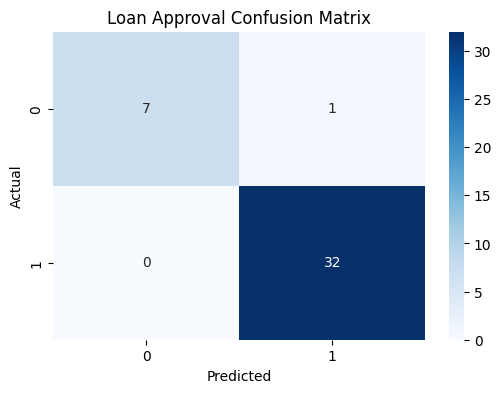

In [26]:
plt.figure(figsize=(6,4))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Loan Approval Confusion Matrix")

plt.show()

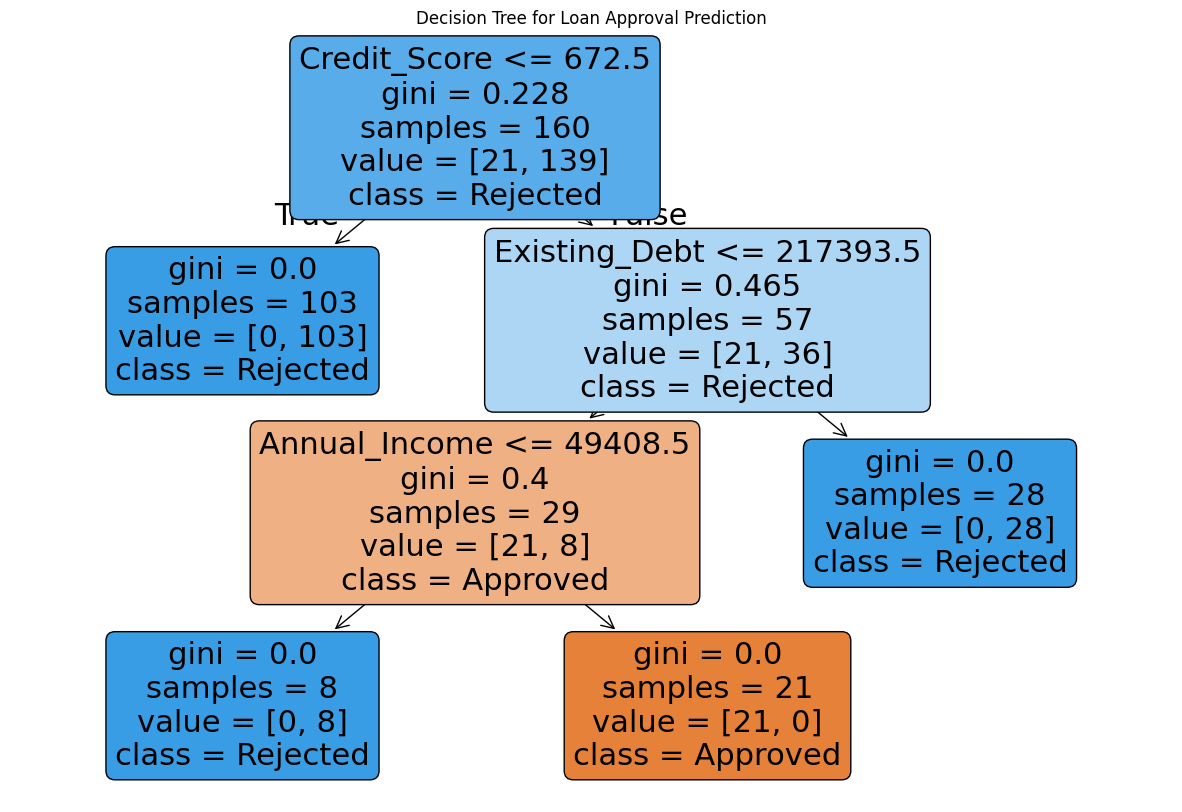

In [27]:
plt.figure(figsize=(15,10))

tree.plot_tree(
    loan_model,
    feature_names=X.columns,
    class_names=["Approved", "Rejected"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree for Loan Approval Prediction")

plt.show()

In [28]:
importance_scores = loan_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance_scores
})

feature_importance

,Feature,Importance
0,Annual_Income,0.317539
1,Credit_Score,0.273003
2,Loan_Amount,0.000000
3,Employment_Status,0.000000
4,Education_Level,0.000000
5,Existing_Debt,0.409458


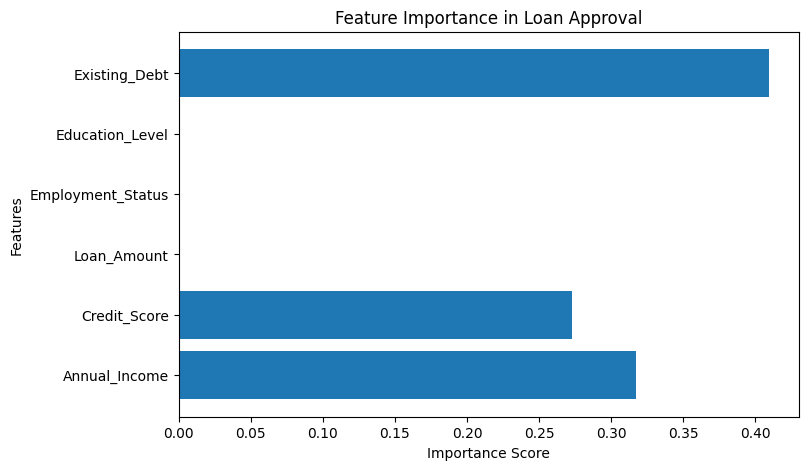

In [29]:
plt.figure(figsize=(8,5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance in Loan Approval")

plt.show()

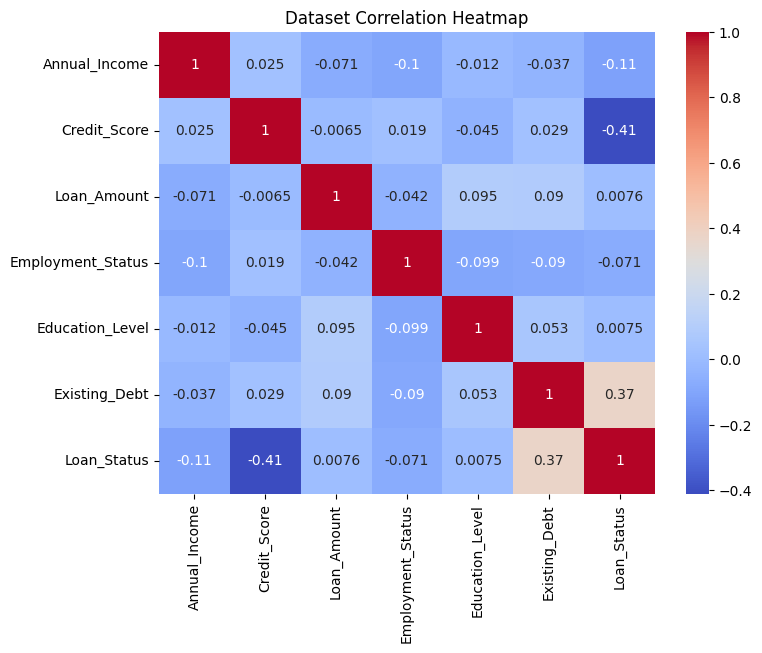

In [30]:
plt.figure(figsize=(8,6))

sns.heatmap(
    loan_data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Dataset Correlation Heatmap")

plt.show()

In [31]:
new_applicant = pd.DataFrame({
    "Annual_Income": [100000],
    "Credit_Score": [750],
    "Loan_Amount": [500000],
    "Employment_Status": [1],
    "Education_Level": [1],
    "Existing_Debt": [100000]
})

prediction = loan_model.predict(new_applicant)

if prediction[0] == 1:
    print("Loan Status : Approved")
else:
    print("Loan Status : Rejected")

Loan Status : Rejected
